# Assignment 3C - Emotion Classifier + LLM Critic

This is the single-file version of the assignment pipeline.

It covers the full workflow:

1. Install/import required packages.
2. Load the Hugging Face `dair-ai/emotion` dataset.
3. Train a TF-IDF + Logistic Regression emotion classifier.
4. Evaluate the model with a classification report and confusion matrix.
5. Explain one prediction with LIME and with classifier word weights.
6. Save `emotion_model.joblib` and `label_names.txt`.
7. Generate `mcp_server.py`, which exposes the trained model as an MCP tool.
8. Test the prediction payload locally.
9. Optionally send the model output to Groq or xAI/Grok as an LLM critic.
10. Zip the generated artifacts for download/submission.

Recommended workflow:

- Google Colab or Kaggle to run the notebook and train the model.
- VS Code to edit the files, inspect the generated artifacts, and test the MCP server locally.
- Use Groq or xAI/Grok for the LLM-in-the-loop critic.

In Colab, use `Runtime -> Run all`.

## 1. Environment setup

This cell installs the core ML/explainability packages if they are missing. The `anthropic` and `mcp` packages are useful for the optional Claude API and local MCP server steps, but the classifier itself can still train without calling Claude.

In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

IN_KAGGLE = Path("/kaggle/working").exists()
ARTIFACT_DIR = Path("/kaggle/working" if IN_KAGGLE else ".").resolve()
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CORE_PACKAGES = {
    "datasets": "datasets",
    "lime": "lime",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}

OPTIONAL_PACKAGES = {
    "groq": "groq",
    "openai": "openai",
    "mcp": "mcp",
}

def ensure_package(module_name, pip_name, required=True):
    if importlib.util.find_spec(module_name) is not None:
        return
    print(f"Installing {pip_name}...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    except Exception as exc:
        if required:
            raise
        print(f"Optional package {pip_name} was not installed: {exc}")

for module_name, pip_name in CORE_PACKAGES.items():
    ensure_package(module_name, pip_name, required=True)

for module_name, pip_name in OPTIONAL_PACKAGES.items():
    ensure_package(module_name, pip_name, required=False)

print("Running in:", "Colab" if IN_COLAB else "Kaggle" if IN_KAGGLE else "local Jupyter")
print("Artifact directory:", ARTIFACT_DIR)

Installing lime...
Installing groq...
Installing mcp...
Running in: Colab
Artifact directory: /content


## 2. Load dataset

Dataset: `dair-ai/emotion`

Labels: sadness, joy, love, anger, fear, surprise.

In [2]:
import json
import numpy as np
import pandas as pd
from datasets import load_dataset

RANDOM_STATE = 42
DATASET_NAME = "dair-ai/emotion"

# Set QUICK_RUN=True while debugging. Use False for the final assignment run.
QUICK_RUN = False
QUICK_TRAIN_ROWS = 3000
QUICK_TEST_ROWS = 600

ds = load_dataset(DATASET_NAME)
label_names = ds["train"].features["label"].names

train_df = ds["train"].to_pandas()
valid_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

if QUICK_RUN:
    train_df = train_df.sample(min(QUICK_TRAIN_ROWS, len(train_df)), random_state=RANDOM_STATE)
    test_df = test_df.sample(min(QUICK_TEST_ROWS, len(test_df)), random_state=RANDOM_STATE)

for frame in (train_df, valid_df, test_df):
    frame["label_name"] = frame["label"].map(lambda i: label_names[int(i)])

print(ds)
print("Labels:", label_names)
print("Train rows:", len(train_df), "| Validation rows:", len(valid_df), "| Test rows:", len(test_df))
display(train_df["label_name"].value_counts().rename("train_count").to_frame())
display(train_df.head())

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Train rows: 16000 | Validation rows: 2000 | Test rows: 2000


,train_count
label_name,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## 3. Train baseline classifier

The model is intentionally simple: TF-IDF features plus Logistic Regression. This makes the model fast to train and easier to inspect, because the classifier coefficients map back to words and n-grams.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)),
    ("clf", LogisticRegression(max_iter=1000, C=5.0, solver="lbfgs")),
])

pipe.fit(train_df["text"], train_df["label"])
preds = pipe.predict(test_df["text"])

report_text = classification_report(
    test_df["label"],
    preds,
    target_names=label_names,
    digits=4,
)
print(report_text)

report_dict = classification_report(
    test_df["label"],
    preds,
    target_names=label_names,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
display(report_df)

accuracy = float(report_dict["accuracy"])
weakest_class = report_df.loc[label_names, "f1-score"].astype(float).idxmin()
weakest_f1 = float(report_df.loc[weakest_class, "f1-score"])

print(f"Test accuracy: {accuracy:.4f}")
print(f"Weakest class by F1: {weakest_class} ({weakest_f1:.4f})")

report_path = ARTIFACT_DIR / "classification_report.csv"
report_df.to_csv(report_path)
print("Saved:", report_path)

              precision    recall  f1-score   support

     sadness     0.8876    0.9243    0.9056       581
         joy     0.8540    0.9424    0.8960       695
        love     0.7874    0.6289    0.6993       159
       anger     0.8984    0.8364    0.8663       275
        fear     0.8878    0.7768    0.8286       224
    surprise     0.7347    0.5455    0.6261        66

    accuracy                         0.8660      2000
   macro avg     0.8416    0.7757    0.8036      2000
weighted avg     0.8644    0.8660    0.8626      2000



,precision,recall,f1-score,support
sadness,0.887603,0.924269,0.905565,581.000
joy,0.853977,0.942446,0.896033,695.000
love,0.787402,0.628931,0.699301,159.000
anger,0.898438,0.836364,0.866290,275.000
fear,0.887755,0.776786,0.828571,224.000
surprise,0.734694,0.545455,0.626087,66.000
accuracy,0.866000,0.866000,0.866000,0.866
macro avg,0.841645,0.775708,0.803641,2000.000
weighted avg,0.864413,0.866000,0.862608,2000.000


Test accuracy: 0.8660
Weakest class by F1: surprise (0.6261)
Saved: /content/classification_report.csv


## 4. Confusion matrix

This shows which emotion labels the classifier confuses most often.

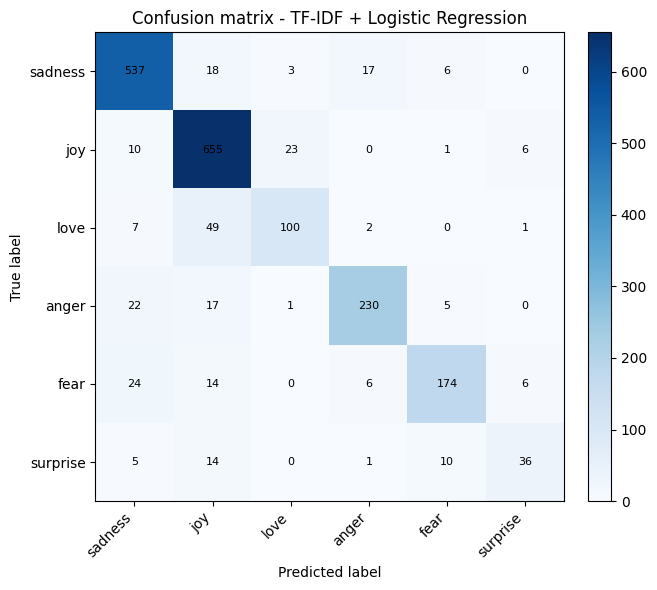

Saved: /content/confusion_matrix.png


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_df["label"], preds, labels=list(range(len(label_names))))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_yticks(range(len(label_names)))
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix - TF-IDF + Logistic Regression")

for i in range(len(label_names)):
    for j in range(len(label_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

confusion_path = ARTIFACT_DIR / "confusion_matrix.png"
plt.savefig(confusion_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", confusion_path)

## 5. Prediction payload with word-weight explanation

This function mirrors what the MCP tool will return to Claude. It includes the predicted label, confidence, all class probabilities, and the highest-impact words/n-grams for the predicted class.

In [5]:
def predict_emotion_payload(text, top_k_words=6):
    probs = pipe.predict_proba([text])[0]
    pred_idx = int(np.argmax(probs))
    pred_label = label_names[pred_idx]

    vec = pipe.named_steps["tfidf"]
    clf = pipe.named_steps["clf"]
    feature_names = np.array(vec.get_feature_names_out())
    row = vec.transform([text])
    nonzero = row.nonzero()[1]

    top_words = []
    if len(nonzero) > 0:
        weights = clf.coef_[pred_idx][nonzero] * row[0, nonzero].toarray().ravel()
        order = np.argsort(-np.abs(weights))[:top_k_words]
        top_words = [
            {
                "term": str(feature_names[nonzero[i]]),
                "weight": round(float(weights[i]), 4),
                "direction": "supports" if weights[i] >= 0 else "opposes",
            }
            for i in order
        ]

    return {
        "text": text,
        "predicted_label": pred_label,
        "confidence": round(float(probs[pred_idx]), 4),
        "all_probabilities": {
            label_names[i]: round(float(p), 4) for i, p in enumerate(probs)
        },
        "top_contributing_words": top_words,
        "note": (
            "This is a simple linear TF-IDF classifier. It cannot reliably "
            "understand sarcasm, negation scope, or context beyond individual "
            "words and n-grams."
        ),
    }

demo_text = "I can't believe you did that, I am speechless"
print(json.dumps(predict_emotion_payload(demo_text), indent=2))

{
  "text": "I can't believe you did that, I am speechless",
  "predicted_label": "sadness",
  "confidence": 0.4179,
  "all_probabilities": {
    "sadness": 0.4179,
    "joy": 0.3432,
    "love": 0.0379,
    "anger": 0.0506,
    "fear": 0.1358,
    "surprise": 0.0148
  },
  "top_contributing_words": [
    {
      "term": "you did",
      "weight": 0.321,
      "direction": "supports"
    },
    {
      "term": "did",
      "weight": 0.215,
      "direction": "supports"
    },
    {
      "term": "can believe",
      "weight": -0.1997,
      "direction": "opposes"
    },
    {
      "term": "believe",
      "weight": 0.1329,
      "direction": "supports"
    },
    {
      "term": "that",
      "weight": -0.1287,
      "direction": "opposes"
    },
    {
      "term": "am",
      "weight": 0.1133,
      "direction": "supports"
    }
  ],
  "note": "This is a simple linear TF-IDF classifier. It cannot reliably understand sarcasm, negation scope, or context beyond individual words and n-g

## 6. LIME explanation

LIME is used as an independent local explainability check. Compare its highlighted words with the coefficient-based word weights above.

Text: 'i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived'
True label: joy
Predicted label: joy


,term,lime_weight
0,optimistic,0.457933
1,slightly,-0.147372
2,red,-0.067182
3,arm,-0.062904
4,my,-0.062303
5,arrived,0.054675
6,of,-0.051951
7,when,-0.042148


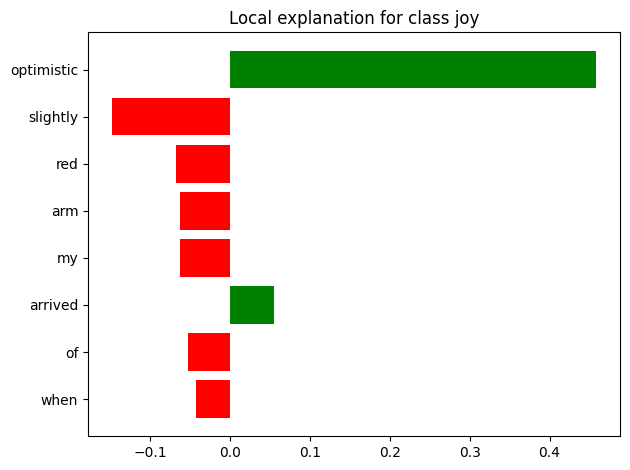

Saved: /content/lime_example.png


In [6]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=label_names)

SAMPLE_INDEX = 3
sample_text = str(test_df.iloc[SAMPLE_INDEX]["text"])
true_idx = int(test_df.iloc[SAMPLE_INDEX]["label"])
pred_idx = int(pipe.predict([sample_text])[0])

exp = explainer.explain_instance(
    sample_text,
    pipe.predict_proba,
    num_features=8,
    labels=[pred_idx],
)

lime_terms = exp.as_list(label=pred_idx)
lime_df = pd.DataFrame(lime_terms, columns=["term", "lime_weight"])

print("Text:", repr(sample_text))
print("True label:", label_names[true_idx])
print("Predicted label:", label_names[pred_idx])
display(lime_df)

fig = exp.as_pyplot_figure(label=pred_idx)
plt.tight_layout()
lime_path = ARTIFACT_DIR / "lime_example.png"
plt.savefig(lime_path, dpi=150, bbox_inches="tight")
plt.show()

lime_df.to_csv(ARTIFACT_DIR / "lime_terms.csv", index=False)
print("Saved:", lime_path)

## 7. Save model artifacts

These files are required by the MCP server:

- `emotion_model.joblib`
- `label_names.txt`

In [7]:
import joblib

model_path = ARTIFACT_DIR / "emotion_model.joblib"
labels_path = ARTIFACT_DIR / "label_names.txt"
summary_path = ARTIFACT_DIR / "run_summary.json"

joblib.dump(pipe, model_path)
labels_path.write_text("\n".join(label_names) + "\n", encoding="utf-8")

run_summary = {
    "dataset": DATASET_NAME,
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "labels": label_names,
    "test_accuracy": round(accuracy, 4),
    "weakest_class_by_f1": weakest_class,
    "weakest_class_f1": round(weakest_f1, 4),
    "model": "TF-IDF(max_features=20000, ngram_range=(1, 2), min_df=2) + LogisticRegression(C=5.0)",
    "artifacts": [
        "emotion_model.joblib",
        "label_names.txt",
        "classification_report.csv",
        "confusion_matrix.png",
        "lime_example.png",
        "lime_terms.csv",
    ],
}

summary_path.write_text(json.dumps(run_summary, indent=2), encoding="utf-8")

print("Saved:", model_path)
print("Saved:", labels_path)
print("Saved:", summary_path)
print(json.dumps(run_summary, indent=2))

Saved: /content/emotion_model.joblib
Saved: /content/label_names.txt
Saved: /content/run_summary.json
{
  "dataset": "dair-ai/emotion",
  "train_rows": 16000,
  "test_rows": 2000,
  "labels": [
    "sadness",
    "joy",
    "love",
    "anger",
    "fear",
    "surprise"
  ],
  "test_accuracy": 0.866,
  "weakest_class_by_f1": "surprise",
  "weakest_class_f1": 0.6261,
  "model": "TF-IDF(max_features=20000, ngram_range=(1, 2), min_df=2) + LogisticRegression(C=5.0)",
  "artifacts": [
    "emotion_model.joblib",
    "label_names.txt",
    "classification_report.csv",
    "confusion_matrix.png",
    "lime_example.png",
    "lime_terms.csv"
  ]
}


## 8. Generate the MCP server file

This cell creates `mcp_server.py` beside the saved model artifacts. The notebook remains the single source file for the assignment, and this generated server file is the artifact to use with VS Code or Codex.

In [8]:
MCP_SERVER_CODE = r'''
"""
Minimal MCP server that wraps a trained TF-IDF + Logistic Regression
emotion classifier and exposes it as a Claude-callable tool.

Required files in the same folder:
  - emotion_model.joblib
  - label_names.txt

Install locally:
    pip install mcp joblib scikit-learn numpy

Test locally:
    mcp dev mcp_server.py
"""

import os
import numpy as np
import joblib
from mcp.server.fastmcp import FastMCP

HERE = os.path.dirname(os.path.abspath(__file__))
MODEL_PATH = os.path.join(HERE, "emotion_model.joblib")
LABELS_PATH = os.path.join(HERE, "label_names.txt")

mcp = FastMCP("emotion-model")

_pipe = None
_label_names = None


def _load():
    global _pipe, _label_names
    if _pipe is None:
        if not os.path.exists(MODEL_PATH):
            raise FileNotFoundError(f"Missing model file: {MODEL_PATH}")
        if not os.path.exists(LABELS_PATH):
            raise FileNotFoundError(f"Missing labels file: {LABELS_PATH}")

        _pipe = joblib.load(MODEL_PATH)
        with open(LABELS_PATH, encoding="utf-8") as f:
            _label_names = [line.strip() for line in f if line.strip()]
    return _pipe, _label_names


@mcp.tool()
def predict_emotion(text: str, top_k_words: int = 6) -> dict:
    """Predict emotion for a short English text.

    Returns the predicted label, confidence, all class probabilities,
    and top weighted words/n-grams for the predicted class.
    """
    pipe, label_names = _load()

    probs = pipe.predict_proba([text])[0]
    pred_idx = int(np.argmax(probs))
    pred_label = label_names[pred_idx]

    vec = pipe.named_steps["tfidf"]
    clf = pipe.named_steps["clf"]
    feature_names = np.array(vec.get_feature_names_out())
    row = vec.transform([text])
    nonzero = row.nonzero()[1]

    top_words = []
    if len(nonzero) > 0:
        weights = clf.coef_[pred_idx][nonzero] * row[0, nonzero].toarray().ravel()
        order = np.argsort(-np.abs(weights))[:top_k_words]
        top_words = [
            {
                "term": str(feature_names[nonzero[i]]),
                "weight": round(float(weights[i]), 4),
                "direction": "supports" if weights[i] >= 0 else "opposes",
            }
            for i in order
        ]

    return {
        "text": text,
        "predicted_label": pred_label,
        "confidence": round(float(probs[pred_idx]), 4),
        "all_probabilities": {
            label_names[i]: round(float(p), 4) for i, p in enumerate(probs)
        },
        "top_contributing_words": top_words,
        "note": (
            "This is a simple linear TF-IDF classifier. It cannot reliably "
            "understand sarcasm, negation scope, or context beyond individual "
            "words and n-grams."
        ),
    }


@mcp.tool()
def dataset_label_distribution() -> dict:
    """Return the label names used by the trained emotion model."""
    _, label_names = _load()
    return {"labels": label_names}


if __name__ == "__main__":
    mcp.run(transport="stdio")
'''

mcp_path = ARTIFACT_DIR / "mcp_server.py"
mcp_path.write_text(MCP_SERVER_CODE.strip() + "\n", encoding="utf-8")
print("Saved:", mcp_path)

Saved: /content/mcp_server.py


## 9. Test the model/tool output locally

This does not start an MCP server inside Colab. Instead, it tests the exact payload shape that the MCP tool returns. For the full MCP test, downloaded the artifacts and run `mcp dev mcp_server.py` locally.

In [9]:
TEST_TEXTS = [
    "I feel so happy and grateful today",
    "I am furious that this happened again",
    "well that was just great, exactly what I needed today",
    "I miss them so much and feel empty",
]

for text in TEST_TEXTS:
    print("=" * 80)
    print(json.dumps(predict_emotion_payload(text), indent=2))

{
  "text": "I feel so happy and grateful today",
  "predicted_label": "joy",
  "confidence": 0.9247,
  "all_probabilities": {
    "sadness": 0.0368,
    "joy": 0.9247,
    "love": 0.0093,
    "anger": 0.0164,
    "fear": 0.0088,
    "surprise": 0.0039
  },
  "top_contributing_words": [
    {
      "term": "happy",
      "weight": 1.321,
      "direction": "supports"
    },
    {
      "term": "happy and",
      "weight": 0.5417,
      "direction": "supports"
    },
    {
      "term": "feel",
      "weight": 0.221,
      "direction": "supports"
    },
    {
      "term": "and grateful",
      "weight": 0.1772,
      "direction": "supports"
    },
    {
      "term": "today",
      "weight": 0.1771,
      "direction": "supports"
    },
    {
      "term": "feel so",
      "weight": -0.1557,
      "direction": "opposes"
    }
  ],
  "note": "This is a simple linear TF-IDF classifier. It cannot reliably understand sarcasm, negation scope, or context beyond individual words and n-grams."


## 10. Optional Groq or xAI/Grok critic

This step demonstrates the LLM-in-the-loop critic pattern without Claude Code.

Using either:

- Groq: set `GROQ_API_KEY`; optionally set `GROQ_MODEL`.
- xAI/Grok: set `XAI_API_KEY`; optionally set `XAI_MODEL`.

In Colab, I stored these in the Secrets panel. If no key is configured, the cell prints the exact prompt I have pasted into any LLM manually.

In [10]:
def make_critic_prompt(payload):
    return f'''A logistic regression emotion classifier returned this tool output:

{json.dumps(payload, indent=2)}

In 3-4 sentences, do you agree with this prediction? If you disagree or think it is ambiguous, say why and name the emotion you would choose. Be honest about cases where the model's word-level reasoning looks shallow, spurious, sarcastic, or affected by negation.'''


def load_secret_if_available(name):
    if os.environ.get(name):
        return os.environ[name]

    if IN_COLAB:
        try:
            from google.colab import userdata  # type: ignore
            value = userdata.get(name)
            if value:
                os.environ[name] = value
                return value
        except Exception:
            pass

    if IN_KAGGLE:
        try:
            from kaggle_secrets import UserSecretsClient  # type: ignore
            value = UserSecretsClient().get_secret(name)
            if value:
                os.environ[name] = value
                return value
        except Exception:
            pass

    return ""


critic_payload = predict_emotion_payload(
    "well that was just great, exactly what I needed today",
    top_k_words=8,
)
critic_prompt = make_critic_prompt(critic_payload)
print(critic_prompt)

groq_key = load_secret_if_available("GROQ_API_KEY").strip()
xai_key = load_secret_if_available("XAI_API_KEY").strip()
groq_model = load_secret_if_available("GROQ_MODEL").strip() or "llama-3.3-70b-versatile"
xai_model = load_secret_if_available("XAI_MODEL").strip() or "latest"

if groq_key:
    from groq import Groq

    client = Groq(api_key=groq_key)
    response = client.chat.completions.create(
        model=groq_model,
        messages=[{"role": "user", "content": critic_prompt}],
        max_tokens=300,
    )
    print("\nGroq critic:\n")
    print(response.choices[0].message.content)

elif xai_key:
    from openai import OpenAI

    client = OpenAI(api_key=xai_key, base_url="https://api.x.ai/v1")
    response = client.chat.completions.create(
        model=xai_model,
        messages=[{"role": "user", "content": critic_prompt}],
        max_tokens=300,
    )
    print("\nxAI/Grok critic:\n")
    print(response.choices[0].message.content)

else:
    print("\nSkipping API call.")
    print("To run the LLM critic here, set either GROQ_API_KEY or XAI_API_KEY, then rerun this cell.")
    print("You can also paste the prompt above into ChatGPT, Grok, Gemini, Copilot, or any other LLM.")

A logistic regression emotion classifier returned this tool output:

{
  "text": "well that was just great, exactly what I needed today",
  "predicted_label": "joy",
  "confidence": 0.8635,
  "all_probabilities": {
    "sadness": 0.0611,
    "joy": 0.8635,
    "love": 0.0134,
    "anger": 0.0136,
    "fear": 0.0438,
    "surprise": 0.0045
  },
  "top_contributing_words": [
    {
      "term": "well",
      "weight": 0.9123,
      "direction": "supports"
    },
    {
      "term": "was just",
      "weight": 0.4189,
      "direction": "supports"
    },
    {
      "term": "exactly",
      "weight": 0.3238,
      "direction": "supports"
    },
    {
      "term": "needed",
      "weight": 0.1926,
      "direction": "supports"
    },
    {
      "term": "that was",
      "weight": -0.1506,
      "direction": "opposes"
    },
    {
      "term": "today",
      "weight": 0.1463,
      "direction": "supports"
    },
    {
      "term": "exactly what",
      "weight": -0.0795,
      "directio

## 11. VS Code + MCP setup after downloading artifacts

Colab generates the model, labels, and server file. VS Code is then used locally to inspect the project and test/connect the MCP server.

I can still satisfy the MCP part by testing with MCP Inspector from the VS Code terminal.

In [11]:
local_setup_instructions = f'''
Download these files from the artifact zip:
  - emotion_model.joblib
  - label_names.txt
  - mcp_server.py

Put them in one folder on your computer and open that folder in VS Code.

In the VS Code terminal, install local dependencies:
    python3 -m venv .venv
    source .venv/bin/activate        # macOS/Linux
    # .venv\\Scripts\\activate       # Windows PowerShell
    pip install mcp joblib scikit-learn numpy

Test the MCP server with MCP Inspector:
    mcp dev mcp_server.py

Optional VS Code MCP configuration:
Create .vscode/mcp.json in the same VS Code workspace:
{{
  "servers": {{
    "emotion-model": {{
      "type": "stdio",
      "command": "python3",
      "args": ["/absolute/path/to/mcp_server.py"]
    }}
  }}
}}

Then restart/start the server from VS Code's MCP tools or Command Palette.
Ask your VS Code AI chat, if available:
    Use the emotion-model MCP tool predict_emotion on:
    "I can't believe you did that, I am speechless"
    Then critique whether the model is right.

If VS Code chat/MCP is not available, the MCP Inspector test plus the Groq/xAI critic cell still demonstrates the professional-tooling requirement.
'''

print(local_setup_instructions)


Download these files from the artifact zip:
  - emotion_model.joblib
  - label_names.txt
  - mcp_server.py

Put them in one folder on your computer and open that folder in VS Code.

In the VS Code terminal, install local dependencies:
    python3 -m venv .venv
    source .venv/bin/activate        # macOS/Linux
    # .venv\Scripts\activate       # Windows PowerShell
    pip install mcp joblib scikit-learn numpy

Test the MCP server with MCP Inspector:
    mcp dev mcp_server.py

Optional VS Code MCP configuration:
Create .vscode/mcp.json in the same VS Code workspace:
{
  "servers": {
    "emotion-model": {
      "type": "stdio",
      "command": "python3",
      "args": ["/absolute/path/to/mcp_server.py"]
    }
  }
}

Then restart/start the server from VS Code's MCP tools or Command Palette.
Ask your VS Code AI chat, if available:
    Use the emotion-model MCP tool predict_emotion on:
    "I can't believe you did that, I am speechless"
    Then critique whether the model is right.

If 

## 12. Package artifacts for download

This creates `assignment3c_artifacts.zip`. In Colab it will try to start a download. In Kaggle, open the notebook Output panel and download the zip from `/kaggle/working`.

In [12]:
import zipfile

artifact_files = [
    ARTIFACT_DIR / "emotion_model.joblib",
    ARTIFACT_DIR / "label_names.txt",
    ARTIFACT_DIR / "mcp_server.py",
    ARTIFACT_DIR / "classification_report.csv",
    ARTIFACT_DIR / "confusion_matrix.png",
    ARTIFACT_DIR / "lime_example.png",
    ARTIFACT_DIR / "lime_terms.csv",
    ARTIFACT_DIR / "run_summary.json",
]

zip_path = ARTIFACT_DIR / "assignment3c_artifacts.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in artifact_files:
        if path.exists():
            zf.write(path, arcname=path.name)

print("Created:", zip_path)
print("Included files:")
for path in artifact_files:
    print(" -", path.name, "OK" if path.exists() else "missing")

if IN_COLAB:
    try:
        from google.colab import files  # type: ignore
        files.download(str(zip_path))
    except Exception as exc:
        print("Automatic Colab download did not start:", exc)
elif IN_KAGGLE:
    print("Kaggle: download the zip from the Output panel:", zip_path)
else:
    print("Local Jupyter: zip is available at:", zip_path)

Created: /content/assignment3c_artifacts.zip
Included files:
 - emotion_model.joblib OK
 - label_names.txt OK
 - mcp_server.py OK
 - classification_report.csv OK
 - confusion_matrix.png OK
 - lime_example.png OK
 - lime_terms.csv OK
 - run_summary.json OK


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Values to paste into the write-up

Use these values and observations in `writeup.md`.

In [13]:
print(f'''
Write-up values:
- Dataset: {DATASET_NAME}
- Model: TF-IDF + Logistic Regression
- Test accuracy: {accuracy:.4f}
- Weakest class by F1: {weakest_class} ({weakest_f1:.4f})
- LIME figure: lime_example.png
- Confusion matrix: confusion_matrix.png

One-line professional tools note:
Google Colab, VS Code, Hugging Face datasets, scikit-learn, LIME, MCP server/Inspector, and Groq or xAI/Grok API.

Reflection prompts:
- Compare the top weighted words from predict_emotion_payload with the LIME terms.
- Test at least one ambiguous or sarcastic sentence and note whether the LLM critic catches the weakness.
- Mention that production would need stronger data validation, calibration, monitoring, drift checks, and human review for disagreements.
''')


Write-up values:
- Dataset: dair-ai/emotion
- Model: TF-IDF + Logistic Regression
- Test accuracy: 0.8660
- Weakest class by F1: surprise (0.6261)
- LIME figure: lime_example.png
- Confusion matrix: confusion_matrix.png

One-line professional tools note:
Google Colab, VS Code, Hugging Face datasets, scikit-learn, LIME, MCP server/Inspector, and Groq or xAI/Grok API.

Reflection prompts:
- Compare the top weighted words from predict_emotion_payload with the LIME terms.
- Test at least one ambiguous or sarcastic sentence and note whether the LLM critic catches the weakness.
- Mention that production would need stronger data validation, calibration, monitoring, drift checks, and human review for disagreements.

